In [36]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score



In [41]:
IMG_DIR = "docs/svm/exercicio/img"

In [42]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')
X.head(), y.value_counts()

(   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
 0    14.23        1.71  2.43               15.6      127.0           2.80   
 1    13.20        1.78  2.14               11.2      100.0           2.65   
 2    13.16        2.36  2.67               18.6      101.0           2.80   
 3    14.37        1.95  2.50               16.8      113.0           3.85   
 4    13.24        2.59  2.87               21.0      118.0           2.80   
 
    flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
 0        3.06                  0.28             2.29             5.64  1.04   
 1        2.76                  0.26             1.28             4.38  1.05   
 2        3.24                  0.30             2.81             5.68  1.03   
 3        3.49                  0.24             2.18             7.80  0.86   
 4        2.69                  0.39             1.82             4.32  1.04   
 
    od280/od315_of_diluted_wines  proline  
 0  

<Figure size 1000x600 with 0 Axes>

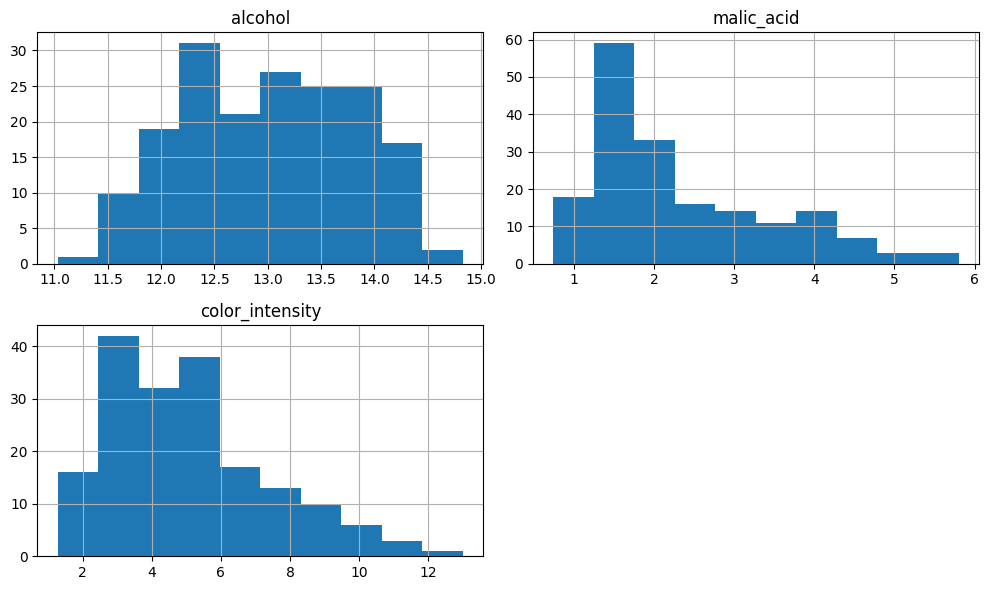

In [46]:
plt.figure(figsize=(10,6))
X[['alcohol','malic_acid','color_intensity']].hist(figsize=(10,6))
plt.tight_layout()
plt.savefig("histogram_features.png", dpi=150)
plt.show()

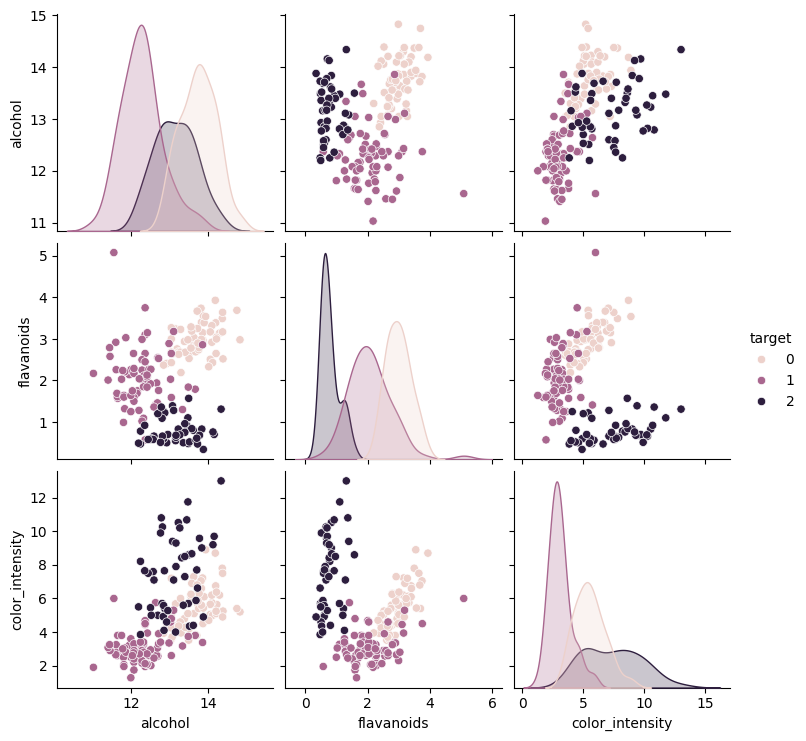

In [47]:
sns.pairplot(pd.concat([X[['alcohol','flavanoids','color_intensity']], y], axis=1), hue='target')
plt.savefig("pairplot_features.png")
plt.show()

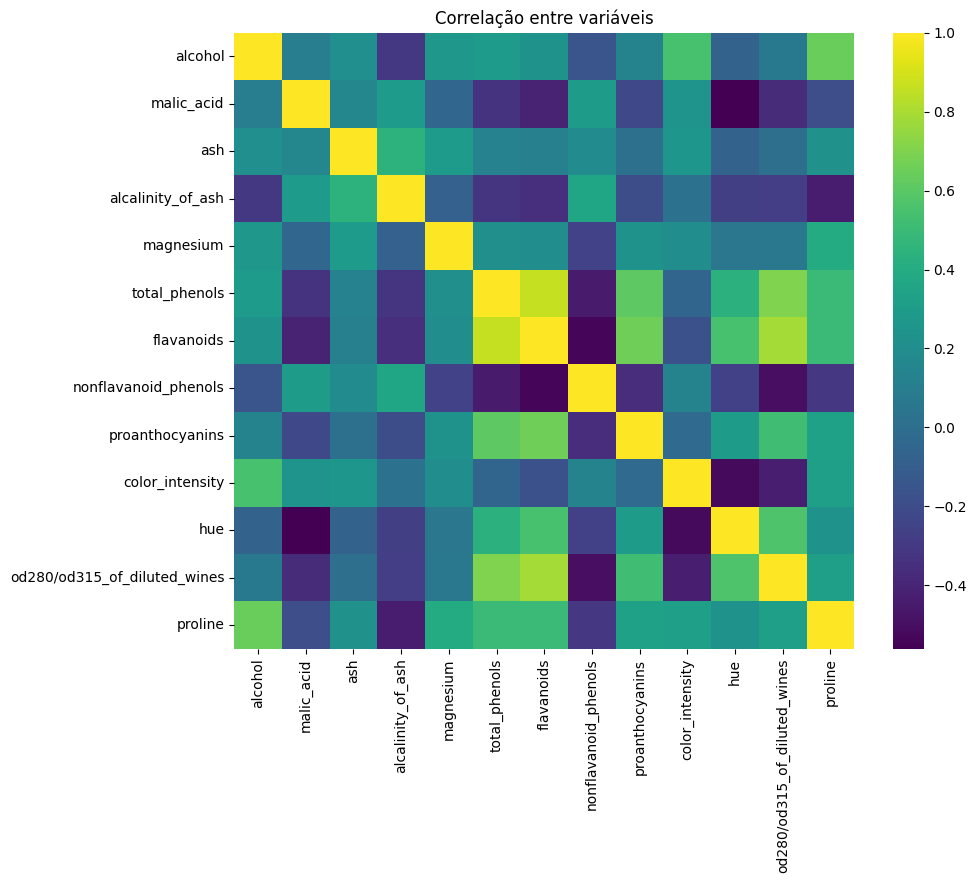

In [48]:
plt.figure(figsize=(10,8))
corr = X.corr()
sns.heatmap(corr, cmap='viridis')
plt.title('Correlação entre variáveis')
plt.savefig("correlation_matrix.png")
plt.show()

In [49]:
#pré-processamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:3]

array([[ 1.51861254, -0.5622498 ,  0.23205254, -1.16959318,  1.91390522,
         0.80899739,  1.03481896, -0.65956311,  1.22488398,  0.25171685,
         0.36217728,  1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, -2.49084714,  0.01814502,
         0.56864766,  0.73362894, -0.82071924, -0.54472099, -0.29332133,
         0.40605066,  1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, -0.2687382 ,  0.08835836,
         0.80899739,  1.21553297, -0.49840699,  2.13596773,  0.26901965,
         0.31830389,  0.78858745,  1.39514818]])

In [50]:
#divisão
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(target
 1    0.401408
 0    0.330986
 2    0.267606
 Name: proportion, dtype: float64,
 target
 1    0.388889
 0    0.333333
 2    0.277778
 Name: proportion, dtype: float64)

In [51]:
svm_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [52]:
#avaliação
y_pred_lin = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)
cm_lin = confusion_matrix(y_test, y_pred_lin)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print('Linear:')
print(cm_lin)
print('RBF:')
print(cm_rbf)

print('\nClassification report (Linear):')
print(classification_report(y_test, y_pred_lin))

print('\nClassification report (RBF):')
print(classification_report(y_test, y_pred_rbf))

print('Precision Linear:', precision_score(y_test, y_pred_lin, average='macro'))
print('Recall Linear:', recall_score(y_test, y_pred_lin, average='macro'))
print('F1 Linear:', f1_score(y_test, y_pred_lin, average='macro'))
print('Precision RBF:', precision_score(y_test, y_pred_rbf, average='macro'))
print('Recall RBF:', recall_score(y_test, y_pred_rbf, average='macro'))
print('F1 RBF:', f1_score(y_test, y_pred_rbf, average='macro'))

Linear:
[[12  0  0]
 [ 1 13  0]
 [ 0  1  9]]
RBF:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]

Classification report (Linear):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36


Classification report (RBF):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

Precision Linear: 0.9505494505494506
Recall Linear: 0.942857142857143
F1 Linear: 0.94531

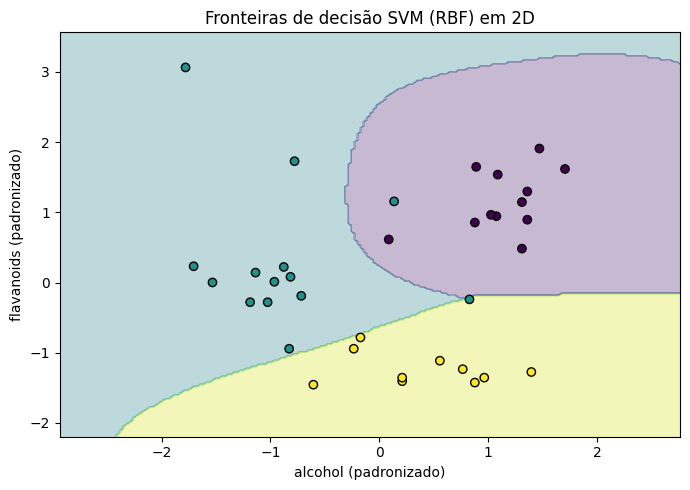

In [53]:
#visualização das margens de decisão

# Selecionamos duas features para visualizar
feat_x = wine.feature_names.index('alcohol')
feat_y = wine.feature_names.index('flavanoids')
X2 = X_scaled[:, [feat_x, feat_y]]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42, stratify=y)
svm2_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm2_rbf.fit(X2_train, y2_train)
# grid para contorno
xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-0.5, X2[:,0].max()+0.5, 200), np.linspace(X2[:,1].min()-0.5, X2[:,1].max()+0.5, 200))
Z = svm2_rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X2_test[:,0], X2_test[:,1], c=y2_test, cmap='viridis', edgecolor='k')
plt.xlabel('alcohol (padronizado)')
plt.ylabel('flavanoids (padronizado)')
plt.title('Fronteiras de decisão SVM (RBF) em 2D')
plt.tight_layout()
plt.savefig("svm_rbf_decision_boundaries.png")
plt.show()